# Parte 1 - Regressão - Student Performances

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df_train = pd.read_csv('regressao/train.csv')
df_test = pd.read_csv('regressao/test.csv')

print(f"Dimensões do treino: {df_train.shape}")
print(f"Dimensões do teste: {df_test.shape}")
df_train.head()

Dimensões do treino: (395, 31)
Dimensões do teste: (40, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


## Análise exploratória (EDA) + limpeza e pre processamento

count    395.000000
mean      10.679139
std        3.696912
min        1.330000
25%        8.330000
50%       10.670000
75%       13.330000
max       19.330000
Name: score, dtype: float64


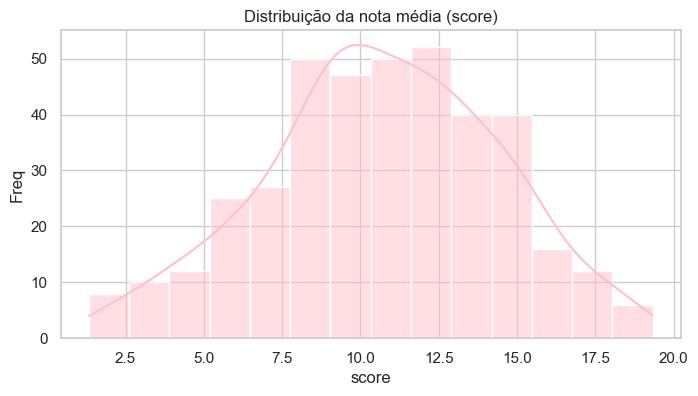

valores nulos no treino: 0
valores nulos no teste: 0


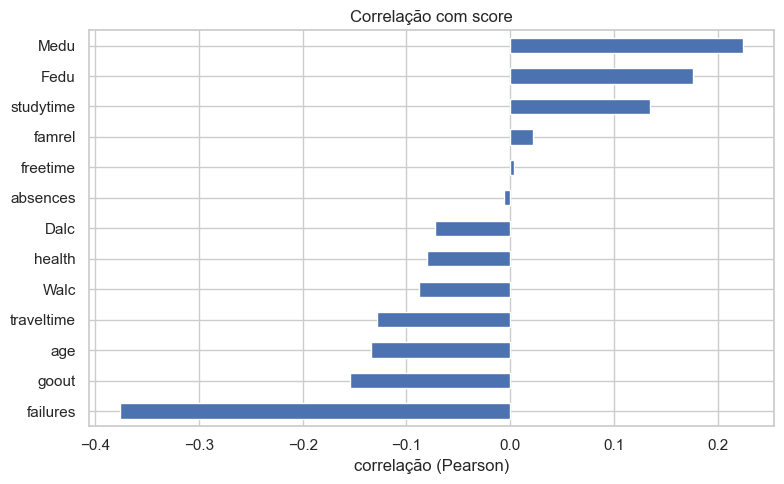

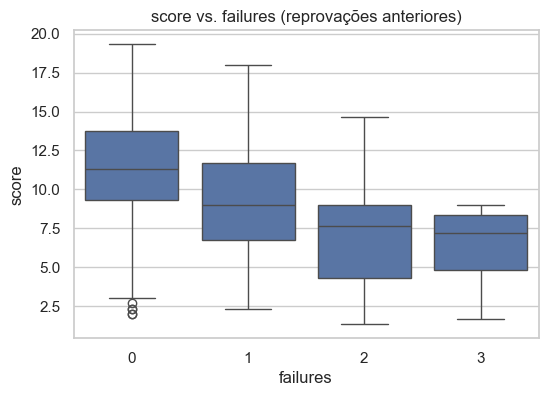

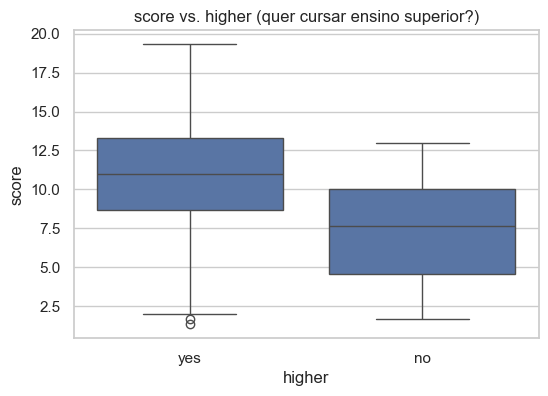

In [96]:
# agora, pra verificar a distribuição de score, valores ausentes, tipos de dados e as correlações

# resumo estatístico da variável:
print(df_train['score'].describe())

# visualizar a distribuição
plt.figure(figsize=(8, 4))
sns.histplot(df_train['score'], kde=True, color='pink')
plt.title('Distribuição da nota média (score)')
plt.xlabel('score')
plt.ylabel('Freq')
plt.show()

# verificar se tem valor nulo
print("valores nulos no treino:", df_train.isnull().sum().sum()) # somar 2 vezes pq a primeira vai ser pra qntd de nulos em cada coluna individualmente e a segunda soma os totais por coluna
print("valores nulos no teste:", df_test.isnull().sum().sum())

corr = df_train.select_dtypes(exclude=['object']).drop(columns=['score']) \
        .corrwith(df_train['score']).sort_values()

# correlação das numéricas/ordinais com score — mostra o que realmente puxa a nota
plt.figure(figsize=(8, 5))
corr.plot(kind='barh')
plt.title('Correlação com score')
plt.xlabel('correlação (Pearson)')
plt.tight_layout()
plt.show()

# score por número de reprovações
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_train, x='failures', y='score')
plt.title('score vs. failures (reprovações anteriores)')
plt.show()

# score por interesse em ensino superior
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_train, x='higher', y='score')
plt.title('score vs. higher (quer cursar ensino superior?)')
plt.show()

-> correlação com 'score':  
`failures` (reprovações anteriores) é, isoladamente, a variável mais
correlacionada com a nota, e é negativa (-0,38), ou seja, quanto mais reprovações no
passado, menor a nota atual. `Medu` e `Fedu` (escolaridade da mãe e do pai)
vêm em seguida, mas positivas (0,22 e 0,18), que expõe que alunos com pais mais escolarizados tendem a notas melhores, provavelmente refletindo mais suporte em casa. `studytime` também é positiva, mas fraca (0,13), sugerindo que tempo de estudo reportado sozinho não explica muito da nota.  

Do lado negativo, `goout` (sair com amigos, -0,15) aparece antes de
`Walc`/`Dalc` (consumo de álcool, ambos abaixo de -0,09), ou seja, o
comportamento social em si parece pesar mais que o consumo de álcool
especificamente. `absences` chama atenção pelo motivo oposto: a correlação é
praticamente zero (-0,006), apesar de ser uma variável que intuitivamente
esperaríamos relacionada a desempenho. Isso não significa que faltar não
afete a nota, só que a relação não é linear (correlação de Pearson só
captura relações lineares); pode haver um efeito só a partir de muitas
faltas, que fica escondido nessa média.  

Nenhuma correlação individual é muito forte (todas abaixo de 0,4 em módulo),
o que já é um sinal de que nenhuma feature sozinha vai prever bem a nota —
faz sentido esperar que os modelos combinem várias features fracas, não que
exista uma "bala de prata".


-> boxplots  
O boxplot de `failures` deixa visual exatamente o que a correlação já indicava: a mediana do `score` cai de forma quase monotônica a cada reprovação a mais — de ~11,3 (0 reprovações, 312 alunos) para ~9,0 (1 reprovação) e ~7,3-7,7 (2 ou 3 reprovações). A queda mais acentuada é logo na primeira reprovação (-2,4 pontos), e depois desacelera — sugerindo que já ter reprovado uma vez é o sinal mais forte, mais do que quantas vezes exatamente.  

Já `higher` (querer cursar ensino superior) mostra a maior diferença que
vimos até agora: quem respondeu "yes" tem nota média de 10,8, contra 7,65 de
quem respondeu "no", uma diferença de mais de 3 pontos.   
Uma ressalva: só 20 dos 395 alunos responderam "no", então essa caixa tem poucos dados e, então, é mais sensível a outliers do que a de "yes". A direção do efeito (motivação para continuar estudando associada a nota melhor) faz sentido, mas o tamanho exato dessa diferença deve ser lido com essa amostra bem pequena (e, consequentemente, não 100% confiável) em mente.

## Modelo de inferência

In [86]:
# tratar colunas categóricas

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold

X = df_train.drop(columns=['score'])
y = df_train['score']

categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object', 'str']).columns.tolist()

# configurar o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# como o train.csv ta ordenado por escola, preciso embaralhar tudo antes de dividir e fixar a semente pro resultado ser reprodutível
kf = KFold(n_splits=5, shuffle=True, random_state=42)


modelos = {
    "Regressão Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Dummy (baseline)": DummyRegressor(strategy="mean") # modelo que chuta a media do score sem olhar nenhum feature. serve de régua:
    # se um modelo de verdade não bater o RMSE dele por uma boa margem, é sinal de que não está aprendendo muito além da média. 
}

results = {}

print("--- RESULTADOS DA VALIDAÇÃO CRUZADA (RMSE) ---")
for name, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('regressor', modelo)
    ])
    # como retorna o mse negativo p maximizar, multiplica por -1 e tira a raiz
    scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    results[name] = rmse_scores.mean()
    print(f"{name:20} | RMSE Médio: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

--- RESULTADOS DA VALIDAÇÃO CRUZADA (RMSE) ---
Regressão Linear     | RMSE Médio: 3.4593 (+/- 0.1110)
Ridge                | RMSE Médio: 3.4464 (+/- 0.1026)
Lasso                | RMSE Médio: 3.3677 (+/- 0.1870)
KNN                  | RMSE Médio: 3.6264 (+/- 0.2171)
SVR                  | RMSE Médio: 3.3607 (+/- 0.2535)
Árvore de Decisão    | RMSE Médio: 4.4811 (+/- 0.3085)
Random Forest        | RMSE Médio: 3.2414 (+/- 0.1788)
Gradient Boosting    | RMSE Médio: 3.3145 (+/- 0.1135)
Dummy (baseline)     | RMSE Médio: 3.6886 (+/- 0.2613)


## Melhor modelo pela métrica de inferência (RMSE)
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

In [ ]:
# pra scolher melhor modelo, usar de base a etapa anterior (modelo com menor RMSE foi o Random Forest)
melhor_nome = min(results, key=results.get)
melhor_modelo = modelos[melhor_nome]
print("Melhor modelo:", melhor_nome)

# criar pipeline final
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', melhor_modelo)
])

# treinar com todos os dados de treino
pipeline_final.fit(X, y)

# fazer as previsões no conjunto de teste
previsoes = pipeline_final.predict(df_test)


# salvar o arquivo
submission = pd.DataFrame({'id': range(len(df_test)), 'score': previsoes})
submission.to_csv('submission.csv', index=False)

print("Arquivo 'submission.csv' gerado com sucesso!")
print(submission.head())


Melhor modelo: Random Forest
Arquivo 'submission.csv' gerado com sucesso!
   id    score
0   0  13.4169
1   1  10.7094
2   2   5.6406
3   3  11.0162
4   4  12.3293


In [98]:
assert len(submission) == len(df_test)
assert submission['score'].isna().sum() == 0
assert submission['score'].between(0, 20).all()
print("linhas:", len(submission))

linhas: 40


# Parte 2 - Classificação - Breast cancer

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_train2 = pd.read_csv('classiicacao/train2.csv')
df_test2 = pd.read_csv('classiicacao/test2.csv')

print(f"Dimensões do conjunto de treino: {df_train2.shape}")
print(f"Dimensões do conjunto de teste: {df_test2.shape}")
df_train.head()



Dimensões do conjunto de treino: (569, 31)
Dimensões do conjunto de teste: (40, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


## Análise exploratória (EDA)

In [90]:


print("\nDistribuição das classes no treino:")
print(df_train2['diagnosis'].value_counts(normalize=True) * 100) # porcentagem de cada classe na coluna ( % de M e % de B)

# ver valores nulos
print(f"\nTotal de valores nulos no treino: {df_train2.isnull().sum().sum()}")



Distribuição das classes no treino:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

Total de valores nulos no treino: 0


Sem valores nulos!

## Pré processamento

In [91]:


from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X2 = df_train2.drop(columns=['diagnosis']) # X é feature
y2 = df_train2['diagnosis'].map({'M': 1, 'B': 0}) # y é alvo
# aqui eu transformei M e B em 0 e 1, respectivamente

numerical_cols_2 = X2.columns.tolist() # todas as colunas ja sao numéricas amem

preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_2)
    ]
)


## Modelo de inferência

In [92]:


from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier

modelos2 = {
    "Regressão Logística": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent")
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results2 = {}

print("--- AVALIAÇÃO DOS MODELOS (ACURÁCIA MÉDIA COM 5-FOLD CV) ---")
for name, modelo in modelos2.items():
    pipeline_clf = Pipeline(steps=[
        ('preprocessor', preprocessor_2),
        ('classifier', modelo)
    ])
    acc_scores = cross_val_score(pipeline_clf, X2, y2, cv=skf, scoring='accuracy')
    results2[name] = acc_scores.mean()
    print(f"{name:22} | Acurácia: {acc_scores.mean():.4f} (+/- {acc_scores.std():.4f})")


--- AVALIAÇÃO DOS MODELOS (ACURÁCIA MÉDIA COM 5-FOLD CV) ---
Regressão Logística    | Acurácia: 0.9737 (+/- 0.0166)
KNN                    | Acurácia: 0.9631 (+/- 0.0179)
Naive Bayes            | Acurácia: 0.9297 (+/- 0.0199)
SVM (RBF)              | Acurácia: 0.9772 (+/- 0.0163)


c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\skle

Árvore de Decisão      | Acurácia: 0.9104 (+/- 0.0279)
Random Forest          | Acurácia: 0.9543 (+/- 0.0128)
Gradient Boosting      | Acurácia: 0.9508 (+/- 0.0245)
Dummy (baseline)       | Acurácia: 0.6274 (+/- 0.0039)


Nota-se que o Dummy bate com os 63% calculados na EDA.....

## Avaliação

Melhor modelo: SVM (RBF) (Acurácia = 0.9772)
--- Resultados para o SVM (RBF) ---
Verdadeiros Negativos (TN - Benignos certos): 353
Falsos Positivos (FP - Alarmes falsos): 4
Falsos Negativos (FN - Malignos perdidos): 9
Verdadeiros Positivos (TP - Malignos certos): 203


c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\skle

<Figure size 600x600 with 0 Axes>

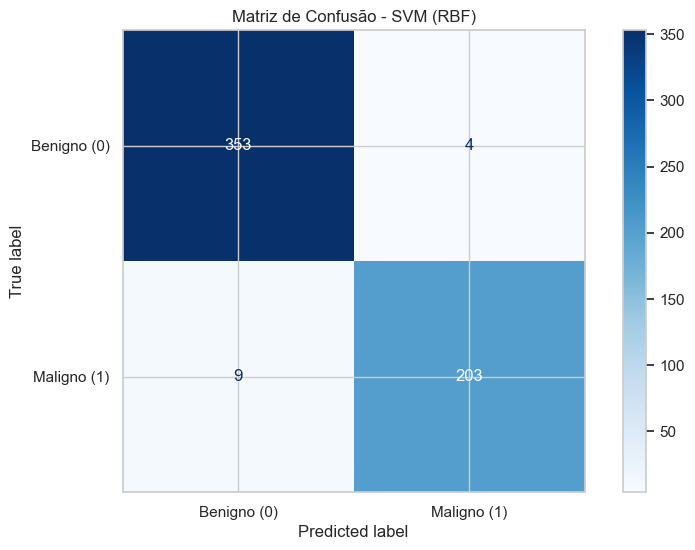

Arquivo 'submission_classificacao.csv' gerado com sucesso usando o SVM (RBF)!
   id  diagnosis
0   0          0
1   1          0
2   2          0
3   3          1
4   4          0
linhas: 40


In [ ]:


from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# melhor modelo foi SVM 
melhor_nome2 = max(
    (n for n in results2 if n != "Dummy (baseline)"),
    key=lambda n: results2[n]  # results2[n] guarda a acurácia média; queremos a maior
)
print(f"Melhor modelo: {melhor_nome2} (Acurácia = {results2[melhor_nome2]:.4f})")
melhor_modelo2 = modelos2[melhor_nome2]

pipeline_melhor = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('classifier', melhor_modelo2)
])

pipeline_melhor.fit(X2, y2)

predicoes_teste = pipeline_melhor.predict(df_test2)

submission_classification = pd.DataFrame({
    'id': range(len(df_test2)),
    'diagnosis': predicoes_teste
})

# tratando falsos positivos e negativos 
y_pred_melhor = cross_val_predict(pipeline_melhor, X2, y2, cv=skf)

# aalculando matriz de confusão
cm = confusion_matrix(y2, y_pred_melhor)
tn, fp, fn, tp = cm.ravel()

print(f"--- Resultados para o {melhor_nome2} ---")
print(f"Verdadeiros Negativos (TN - Benignos certos): {tn}")
print(f"Falsos Positivos (FP - Alarmes falsos): {fp}")
print(f"Falsos Negativos (FN - Malignos perdidos): {fn}")
print(f"Verdadeiros Positivos (TP - Malignos certos): {tp}")

# gráfico da matriz de confusão
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno (0)', 'Maligno (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f"Matriz de Confusão - {melhor_nome2}")
plt.show()


assert len(submission_classification) == len(df_test2)
assert submission_classification['diagnosis'].isna().sum() == 0
assert submission_classification['diagnosis'].isin([0, 1]).all()
submission_classification.to_csv('submission_classificacao.csv', index=False)
print(f"Arquivo 'submission_classificacao.csv' gerado com sucesso usando o {melhor_nome2}!")
print(submission_classification.head())



Clinicamente, um falso negativo (diz que é "benigno" quando, na verdade, é "maligno") é um GRAVE erro, já que deixa um câncer passar sem diagnóstico e, consequentemente, sem tratamente cedo.  
Por isso a escolha do melhor modelo priorizou minimizar FN, não
só a acurácia.   
O SVM (RBF) tem a maior acurácia (97,7%) && o menor número
de falsos negativos entre os modelos testados, o que o torna a escolha mais segura para esse problema (mesmo tendo 1 falso positivo a mais que a Regressão Logística, o custo de um FP, um exame extra, é bem menor que o de um FN).

In [94]:
# comparacção entre todos os modelos

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix

# mesmo skf usado na comparação de acurácia — garante que todos os modelos
# sejam avaliados exatamente nos mesmos folds, pra comparação ser justa
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

comparacao = []
for name, modelo in modelos2.items():
    if name == "Dummy (baseline)":
        continue  # baseline não tem falsos positivos/negativos relevantes de comparar

    pipe = Pipeline([('preprocessor', preprocessor_2), ('classifier', modelo)])
    y_pred_cv = cross_val_predict(pipe, X2, y2, cv=skf)
    tn, fp, fn, tp = confusion_matrix(y2, y_pred_cv).ravel()
    acuracia = (tn + tp) / (tn + fp + fn + tp)

    comparacao.append({
        "modelo": name,
        "acuracia": round(acuracia, 4),
        "FN": fn,   # maligno classificado como benigno — erro mais grave
        "FP": fp,   # benigno classificado como maligno — exame extra
        "TN": tn,
        "TP": tp,
    })

comparacao_df = pd.DataFrame(comparacao).sort_values("FN").reset_index(drop=True)
comparacao_df

c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana\AppData\Local\Programs\Python\Python314\Lib\site-packages\skle

,modelo,acuracia,FN,FP,TN,TP
0,SVM (RBF),0.9772,9,4,353,203
1,Regressão Logística,0.9736,12,3,354,200
2,Random Forest,0.9543,14,12,345,198
3,KNN,0.9631,16,5,352,196
4,Gradient Boosting,0.9508,19,9,348,193
5,Naive Bayes,0.9297,23,17,340,189
6,Árvore de Decisão,0.9104,30,21,336,182


In [95]:
print("linhas:", len(submission_classification))

linhas: 40
